In [3]:
import os
import torchio as tio

# pra usar cpu, descomentar linha abaixo
#os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

import numpy as np
import math
import nibabel as nib

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder
from sklearn.utils import shuffle

import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, CSVLogger, EarlyStopping
from tensorflow.keras.layers import Input, Conv3D, MaxPooling3D, Flatten, Dense, Dropout, BatchNormalization, LeakyReLU
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.regularizers import l2
from tensorflow.keras import layers, models, Input, Model

import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
import numpy as np
import gc
import seaborn as sns

from reportlab.lib.pagesizes import letter
from reportlab.pdfgen import canvas
from PIL import Image
import tempfile
import random

#import wandb

/mnt/c/Users/Bruno/Documents/GitHub/Alzheimer-CNN-Detection/3dalz/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2025-12-10 14:15:08.403016: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-12-10 14:15:08.946081: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-12-10 14:15:09.150943: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already b

In [4]:
from tensorflow.keras import mixed_precision

gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)  # Evita uso excessivo de memória
        print("GPU habilitada com sucesso!")
        print("Memory Growth habilitado para a GPU")
    except RuntimeError as e:
        print(e)

mixed_precision.set_global_policy("mixed_float16")

tf.get_logger().setLevel('ERROR')

GPU habilitada com sucesso!
Memory Growth habilitado para a GPU


I0000 00:00:1765386985.190595    4111 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1765386985.241783    4111 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1765386985.241822    4111 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.


In [5]:
# FUNÇÕES

# Função para carregar imagens NIfTI, seus rótulos e cortar as imagens
def load_nifti_paths(base_dir, class_names):
    image_paths = []
    labels = []
    
    # Caminhos das subpastas
    for label in class_names:
        label_dir = os.path.join(base_dir, label)
        for fname in os.listdir(label_dir):
            img_path = os.path.join(label_dir, fname)
            image_paths.append(img_path)
            labels.append(label)

    # Codificando os rótulos
    label_encoder = LabelEncoder()

    # Inverter a ordem das classes explicitamente
    label_encoder.classes_ = np.array(class_names)

    # Codificando os rótulos (agora 'cn' será 0 e 'ad' será 1)
    labels_array = np.array(labels)
    labels_encoded = label_encoder.transform(labels_array)

    # Transformando os rótulos para one-hot encoding
    labels_one_hot = to_categorical(labels_encoded, num_classes=len(class_names))

    # Embaralhar os dados
    image_paths, labels_one_hot = shuffle(image_paths, labels_one_hot, random_state=42)

    return image_paths, labels_one_hot, label_encoder.classes_

def load_nifti_data_balanced(base_dir, class_names, target=1000):
    images = []
    labels = []
    paths = []
    
    # Caminhos das subpastas
    for label in class_names:
        print(f"carregando diretório {label}")
        label_dir = os.path.join(base_dir, label)
        count = 0

        names = os.listdir(label_dir)
        for fname in names:
            img_path = os.path.join(label_dir, fname)
            img = nib.load(img_path).get_fdata(dtype=np.float16)
            paths.append(img_path)
            images.append(img)
            labels.append(label)
            count += 1

        print(f"diretório carregado {count}")

    # Codificando os rótulos
    label_encoder = LabelEncoder()
    label_encoder.classes_ = np.array(class_names)
    labels_encoded = label_encoder.transform(labels)
    labels_one_hot = to_categorical(labels_encoded, num_classes=len(class_names))

    # Convertendo para arrays NumPy
    images = np.array(images).reshape((-1, *images[0].shape, 1))
    labels_one_hot = np.array(labels_one_hot)
    
    # Embaralhar os dados
    images, labels_one_hot, paths = shuffle(images, labels_one_hot, paths, random_state=42)
    
    return images, labels_one_hot, paths, label_encoder.classes_

def load_nifti_data_balanced_preallocated(base_dir, class_names, augment=False, target_per_class=1000):
    
    available_transforms = [
        tio.RandomBlur(p=1.0),
        tio.RandomNoise(p=1.0, std=(0, 0.05)),
        tio.RandomAnisotropy(p=1.0),
        tio.RandomElasticDeformation(p=1.0),
        tio.RandomBiasField(p=1.0),
        tio.RandomMotion(p=1.0),
        tio.RandomSpike(p=1.0),
        tio.RandomGhosting(p=1.0),
    ]

    all_paths = []
    all_labels = []
    print("Passo 1: Coletando lista de arquivos...")
    for label in class_names:
        label_dir = os.path.join(base_dir, label)
        count = 0
        names = os.listdir(label_dir)
        for fname in names:
            if count < target_per_class:
                all_paths.append(os.path.join(label_dir, fname))
                all_labels.append(label)
                count += 1
    print(f"Total de {len(all_paths)} imagens encontradas.")

    label_encoder = LabelEncoder()
    label_encoder.classes_ = np.array(class_names)
    labels_encoded = label_encoder.transform(all_labels)
    labels_one_hot = to_categorical(labels_encoded, num_classes=len(class_names)).astype(np.float16) 
    
    all_paths_shuffled, labels_one_hot_shuffled = shuffle(all_paths, labels_one_hot, random_state=42)
    
    del all_labels, labels_encoded, labels_one_hot
    gc.collect()

    if not all_paths_shuffled:
        print("Nenhuma imagem encontrada.")
        return np.array([]), np.array([]), [], label_encoder.classes_

    print("Passo 2: Determinando o shape da imagem...")
    try:
        first_img_nib = nib.load(all_paths_shuffled[0])
        img_shape = first_img_nib.get_fdata(dtype=np.float16).shape
    except Exception as e:
        print(f"Erro ao carregar a primeira imagem: {e}")
        return

    total_images = len(all_paths_shuffled)
    print(f"Shape detectado: {img_shape}. Alocando memória para {total_images} imagens...")
    
    images_final = np.empty((total_images, *img_shape, 1), dtype=np.float16)
    paths_final = [None] * total_images

    print("Passo 3: Carregando e transformando imagens...")
    for i in range(total_images):
        img_path = all_paths_shuffled[i]
        try:
            img_nib = nib.load(img_path)
            img_data_f16 = img_nib.get_fdata(dtype=np.float16)
            
            if augment:
                # Seleciona aleatoriamente de 1 a 6 transformações do pool
                num_transforms = random.randint(1, 6)
                selected_transforms = random.sample(available_transforms, num_transforms)
                transform_composer = tio.Compose(selected_transforms)

                img_data_f32 = img_data_f16.astype(np.float32)
                subject = tio.Subject(
                    mri=tio.ScalarImage(tensor=img_data_f32[np.newaxis, ...], affine=img_nib.affine)
                )
                # Aplica a composição
                transformed_data_f32 = transform_composer(subject).mri.data.numpy().squeeze(axis=0)
                img_final = transformed_data_f32.astype(np.float16)
                
                del img_data_f32, subject, transformed_data_f32, transform_composer, selected_transforms
            else:
                img_final = img_data_f16
            
            images_final[i] = img_final.reshape((*img_shape, 1))
            paths_final[i] = img_path

        except Exception as e:
            print(f"Erro em {img_path}: {e}. Inserindo array vazio.")
            images_final[i] = np.zeros((*img_shape, 1), dtype=np.float16)
            paths_final[i] = img_path
        
        if (i + 1) % 50 == 0:
            gc.collect()
            print(f"Processado {i + 1}/{total_images}...")
            
    print("Passo 4: Carregamento concluído.")
    return images_final, labels_one_hot_shuffled, paths_final, label_encoder.classes_

def nifti_data_generator_3d(images_array, labels, batch_size):
    total_n = len(images_array)
    if total_n == 0:
        raise ValueError("O Generator recebeu uma lista vazia de imagens! Verifique o carregamento dos dados.")

    while True:
        for i in range(0, total_n, batch_size):
            final = min(i + batch_size, total_n)
            batch_images = np.array(images_array[i: final])
            batch_labels = np.array(labels[i:final])
            
            yield batch_images, batch_labels

# Função para carregar imagens NIfTI, seus rótulos e cortar as imagens
def nifti_data_generator_3d_path(image_paths, labels, batch_size, size):
    cache_size = batch_size*size
    while True:
        for i in range(0, len(image_paths), cache_size):
            final = min(i + cache_size, len(image_paths))
            batch_paths = image_paths[i:final]
            batch_labels = labels[i:final]
            images = []

            for path in batch_paths:
                # Carregar a imagem NIfTI e garantir o formato correto
                img = nib.load(path).get_fdata(dtype=np.float16) 
                img = img[..., np.newaxis] 
                images.append(img)
            
            # Converter lista para array NumPy e garantir o shape correto
            images = np.array(images) 
            batch_labels = np.array(batch_labels)

            # Liberar memória
            gc.collect()
            
            yield images, batch_labels

# realizar predições e armazenar em um vetor
def get_predictions(images, labels, batch_size, best_model):
    pred = []

    for i in range(0, len(images), batch_size):
        final = min(i + batch_size, len(images))
        
        # Fazendo predição para o lote atual
        batch_pred = best_model.predict(images[i:final])
        pred.append(batch_pred)

    # Concatenando as predições e os rótulos verdadeiros
    pred = np.concatenate(pred)

    # Convertendo as predições para rótulos (a classe com maior probabilidade)
    true_labels = np.argmax(labels, axis=1)
    pred_labels = np.argmax(pred, axis=1)
    return pred_labels, true_labels, pred

def plot_training_history(history, dir, title='training_history.png'):
    plt.figure(figsize=(12, 4))

    # Plot Loss
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Loss Graphic')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    # Plot Accuracy
    plt.subplot(1, 2, 2)
    plt.plot(history.history['categorical_accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_categorical_accuracy'], label='Validation Accuracy')
    plt.title('Accuracy Graphic')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.savefig(os.path.join(dir, title))

    plt.show()

def plot_confusion_matrix(y_true, y_pred, dir, subset, class_names):
    cm = confusion_matrix(y_true, y_pred)

    # Plotando a matriz de confusão
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names,  annot_kws={"size": 14})
    plt.xlabel('Previsões')
    plt.ylabel('Valores Reais')
    plt.title(f'Matriz de Confusão - {subset}')
    plt.savefig(f'{dir}/{subset}_confusion_matrix.png')
    plt.show()

def get_classification_report(y_true, y_pred, dir, subset):
    report = classification_report(y_true, y_pred)
    print(report)

    # Escrevendo o relatório em um arquivo .txt
    with open(os.path.join(dir, f"{subset}_classification_report.txt"), "w") as file:
        file.write(report)

# Função para carregar uma imagem NIfTI e extrair uma fatia específica do eixo Z
def load_nifti_image_pdf(file_path):
    img = nib.load(file_path) 
    data = img.get_fdata(dtype=np.float16)  
    slice_2d = data[2, :, :]
    return slice_2d

# Função para criar o PDF
def create_pdf(y_paths, y_images, y_true_labels, y_pred_labels, y_pred, output_pdf_path, class_names):
    c = canvas.Canvas(output_pdf_path, pagesize=letter)
    width, height = letter  # Dimensões da página no PDF

    #for image, name in zip(y_images, y_paths):
    for i in range(0, len(y_images)):
        true = ''
        pred = ''
        # Carregar a imagem NIfTI e obter a fatia 2D no eixo Z
        # nifti_image = load_nifti_image_pdf(item)
        nifti_image = y_images[i][:, :, 88, 0]

        # Converter a fatia 2D para uma imagem 8-bit (grayscale) para visualização
        img = Image.fromarray(np.uint8(nifti_image / np.max(nifti_image) * 255))  # Normalizar e converter
        img = img.convert("RGB")  # Garantir que a imagem tenha 3 canais (RGB)

        # Redimensionar a imagem para se ajustar ao tamanho da página
        img_width, img_height = img.size
        aspect_ratio = img_height / float(img_width)
        new_width = width * 0.2  # Definir largura como 80% da largura da página
        new_height = new_width * aspect_ratio
        img = img.resize((int(new_width), int(new_height)))

        # Criar um arquivo temporário para salvar a imagem
        with tempfile.NamedTemporaryFile(delete=False, suffix=".png") as temp_file:
            temp_file_path = temp_file.name
            img.save(temp_file_path)

        # configurar para printar as 7 fatias em uma página inteira, com as informações de label predito e esperado

        # Colocar a imagem no PDF usando o caminho temporário
        if i % 12 < 4:
            x = 80
        elif i % 12 < 8:
            x = width - 2.35*new_width - 80
        else:
            x = width - new_width - 80

        y = height - (new_height + 80)*((i%4)+1)

        c.drawImage(temp_file_path, x, y, width=new_width, height=new_height)

        # Escrever os rótulos
        true_label = y_true_labels[i]
        pred_label = y_pred_labels[i]

        #ver como transformar os labels de maneira inteligente
        true = class_names[true_label]
        pred = class_names[pred_label]

        # Definir a cor para os rótulos
        if true_label == pred_label:
            pred_color = (0, 1, 0)  # Verde
        else:
            pred_color = (1, 0, 0)  # Vermelho
        
        #Nome paciente (em preto)
        c.setFont("Helvetica", 12)
        c.setFillColorRGB(0, 0, 0)  # Preto
        c.drawString(x+24, y+new_height+50, f"{os.path.basename(y_paths[i])}")

        # Rótulo esperado (em preto)
        c.setFont("Helvetica", 12)
        c.setFillColorRGB(0, 0, 0)  # Preto
        c.drawString(x+26, y+new_height+35, f"Expected: {true}")

        # Rótulo predito
        c.setFont("Helvetica", 12)
        c.setFillColorRGB(*pred_color)  # Verde ou Vermelho
        c.drawString(x+26, y+new_height+20, f"Predicted: {pred}")

        # Rótulo predito
        c.setFont("Helvetica", 12)
        c.setFillColorRGB(*pred_color)  # Verde ou Vermelho
        c.drawString(x+26, y+new_height+5, f"Prob: {max(y_pred[i])*100:.2f}%")

        # Avançar para a próxima imagem
        i += 1
        
        # Adicionar uma nova página no PDF a cada 2 imagens (se necessário)
        if i % 12 == 0:
            c.showPage()

    # Salvar o PDF
    c.save()

def plot_custom_confusion_matrix(cm, y_labels, x_labels, dir, subset):
    plt.figure(figsize=(10, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=x_labels, yticklabels=y_labels, 
                annot_kws={"size": 14})
    plt.xlabel('Previsões')
    plt.ylabel('Valores Reais')
    plt.title(f'Matriz de Confusão - {subset}')
    plt.savefig(f'{dir}/{subset}_custom_confusion_matrix.png', bbox_inches='tight')
    plt.show()

def create_model_3d(input_shape, n_classes):
    inputs = Input(shape=input_shape)  # (D, H, W, C)

    # Camada 1
    x = layers.Conv3D(4, (3, 3, 3), padding='same', kernel_regularizer=l2(0.01))(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(negative_slope=0.3)(x)
    x = layers.AveragePooling3D(pool_size=(3, 3, 3), padding='same')(x)
    x = layers.Dropout(0.3)(x)

    # Camada 2
    x = layers.Conv3D(8, (3, 3, 3), padding='same', kernel_regularizer=l2(0.01))(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(negative_slope=0.3)(x)
    x = layers.AveragePooling3D(pool_size=(3, 3, 3), padding='same')(x)
    x = layers.Dropout(0.3)(x)

    # Camada 3
    x = layers.Conv3D(16, (3, 3, 3), padding='same', kernel_regularizer=l2(0.01))(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(negative_slope=0.3)(x)
    x = layers.AveragePooling3D(pool_size=(3, 3, 3), padding='same')(x)
    x = layers.Dropout(0.3)(x)

    # # Camada 4
    # x = layers.Conv3D(32, (3, 3, 3), padding='same', kernel_regularizer=l2(0.01))(x)
    # x = layers.BatchNormalization()(x)
    # x = layers.LeakyReLU(negative_slope=0.3)(x)
    # # x = layers.MaxPooling3D(pool_size=(2, 2, 2), padding='same')(x)
    # x = layers.Dropout(0.3)(x)

    # Flatten e densas
    x = layers.Flatten()(x)

    x = layers.Dense(16, kernel_regularizer=l2(0.01))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)
    x = layers.LeakyReLU(negative_slope=0.3)(x)

    outputs = layers.Dense(n_classes, activation='softmax')(x)

    model = models.Model(inputs=inputs, outputs=outputs)

    return model

In [ ]:
# Definindo caminhos
dir_base = "/mnt/c/Users/Paulo Pires/Desktop/Alzheimer_cnn"

train_dir = f'{dir_base}/ADNI/ADNI_NORMALIZED/train'
val_dir = f'{dir_base}/ADNI/ADNI_NORMALIZED/validation'
test_dir = f'{dir_base}/ADNI/ADNI_NORMALIZED/test'

fine_tunning_train_dir = f'{dir_base}/OASIS/OASIS_1_FSL_NORMALIZED/train'
fine_tunning_val_dir = f'{dir_base}/OASIS/OASIS_1_FSL_NORMALIZED/validation'

oasis_train = f'{dir_base}/OASIS/OASIS_1_FSL_NORMALIZED/train'
oasis_validation = f'{dir_base}/OASIS/OASIS_1_FSL_NORMALIZED/validation'

results_dir_base = f'{dir_base}/ADNI/ADNI_NORMALIZED/results/ruidos_pre_treino_fixo'
os.makedirs(results_dir_base, exist_ok=True)

transformations = ['noise']

# Nome das classes
adni_class_names = ['cn', 'mci', 'ad']
oasis_class_names = ['0.0', '0.5', '1.0']

n_adni_classes = len(adni_class_names)
n_oasis_classes = len(oasis_class_names)

PermissionError: [Errno 13] Permission denied: '/mnt/c/Users/Paulo Pires'

In [ ]:
n = len(os.listdir(results_dir_base))

if (n > 0):
    if (len(os.listdir(os.path.join(results_dir_base, f'test_{n}'))) < 3): 
        for item in os.listdir(os.path.join(results_dir_base, f"test_{n}")):
            os.remove(os.path.join(results_dir_base,  f"test_{n}", item))
        os.removedirs(os.path.join(results_dir_base, f'test_{n}'))
        n -= 1

folder_name = f"test_{str(n)}"
results_dir = os.path.join(results_dir_base, folder_name)
os.makedirs(results_dir, exist_ok=True)
print(f"pasta {folder_name} criada")

NameError: name 'os' is not defined

# Transfer learning

In [18]:
train_images_fine_tunning, train_labels_fine_tunning, train_paths_fine_tunning, class_labels_fine_tunning = load_nifti_data_balanced_preallocated(
    fine_tunning_train_dir, 
    oasis_class_names, 
    augment=True
)

print(f"N treino: {len(train_images_fine_tunning)}")

val_images_fine_tunning, val_labels_fine_tunning, val_paths_fine_tunning, _ = load_nifti_data_balanced_preallocated(
    fine_tunning_val_dir, 
    oasis_class_names, 
    augment=True
)

print(f"N validation: {len(val_paths_fine_tunning)}")

Passo 1: Coletando lista de arquivos...
Total de 164 imagens encontradas.
Passo 2: Determinando o shape da imagem...
Shape detectado: (156, 195, 160). Alocando memória para 164 imagens...
Passo 3: Carregando e transformando imagens...
Processado 50/164...
Processado 100/164...
Processado 150/164...
Passo 4: Carregamento concluído.
N treino: 164
Passo 1: Coletando lista de arquivos...
Total de 69 imagens encontradas.
Passo 2: Determinando o shape da imagem...
Shape detectado: (156, 195, 160). Alocando memória para 69 imagens...
Passo 3: Carregando e transformando imagens...
Processado 50/69...
Passo 4: Carregamento concluído.
N validation: 69


In [ ]:
fase_atual = 1
print("--- INICIANDO FASE 2: FINE-TUNING ---")

pretrained_model_path = f"{dir_base}/ADNI/ADNI_NORMALIZED/modelo_pretrained.keras"

# CARREGA O MODELO DA FASE 1
if not os.path.exists(pretrained_model_path):
    raise FileNotFoundError(f"Modelo pré-treinado não encontrado em {pretrained_model_path}. Rode a Fase 1 primeiro.")

print(f"Carregando pesos de: {pretrained_model_path}")
base_model = load_model(pretrained_model_path)

# --- CONGELAMENTO E ADAPTAÇÃO ---
# 1. Remover a camada de classificação antiga e adicionar uma nova (ADnetEx)
# Pega a saída da camada anterior à última
x = base_model.layers[-2].output 

# Adiciona nova camada de classificação inicializada aleatoriamente
predictions = layers.Dense(n_oasis_classes, activation='softmax', name='new_output')(x)

model = models.Model(inputs=base_model.input, outputs=predictions)

# 2. Congelar camadas iniciais (Freezing)
# Vamos congelar as primeiras 7 camadas (aprox. o primeiro bloco convolucional)
for layer in model.layers[:7]:
    layer.trainable = False
    print(f"Camada congelada: {layer.name}")

# 3. Recompilar
# Usar mesmo learning_rate do pre_treino
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005), 
                loss='categorical_crossentropy', 
                metrics=['categorical_accuracy'])

model.summary()

--- INICIANDO FASE 2: FINE-TUNING ---
Carregando pesos de: /mnt/c/Users/Paulo Pires/Desktop/Alzheimer_cnn/ADNI/ADNI_NORMALIZED/results/ruidos_pre_treino/test_5/modelo_pretrained.keras
Camada congelada: input_layer
Camada congelada: conv3d
Camada congelada: batch_normalization
Camada congelada: leaky_re_lu
Camada congelada: average_pooling3d
Camada congelada: dropout
Camada congelada: conv3d_1


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 156, 195, 160,  │             0 │
│                                 │ 1)                     │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3d (Conv3D)                 │ (None, 156, 195, 160,  │           112 │
│                                 │ 4)                     │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 156, 195, 160,  │            16 │
│ (BatchNormalization)            │ 4)                     │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 156, 195, 160,  │             0 │
│                                 │ 4)                     │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling3d               │ (None, 52, 65, 54, 4)  │             0 │
│ (AveragePooling3D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 52, 65, 54, 4)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3d_1 (Conv3D)               │ (None, 52, 65, 54, 8)  │           872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 52, 65, 54, 8)  │            32 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 52, 65, 54, 8)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling3d_1             │ (None, 18, 22, 18, 8)  │             0 │
│ (AveragePooling3D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 18, 22, 18, 8)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3d_2 (Conv3D)               │ (None, 18, 22, 18, 16) │         3,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 18, 22, 18, 16) │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 18, 22, 18, 16) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling3d_2             │ (None, 6, 8, 6, 16)    │             0 │
│ (AveragePooling3D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 6, 8, 6, 16)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │        73,744 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16)             │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 16)             │             

 Total params: 78,427 (306.36 KB)

 Trainable params: 77,347 (302.14 KB)

 Non-trainable params: 1,080 (4.22 KB)

In [ ]:
batch_size = 64

steps_per_epoch = math.ceil(len(train_images_fine_tunning) / batch_size)
validation_steps = math.ceil(len(val_images_fine_tunning) / batch_size)

train_generator_fine_tunning = nifti_data_generator_3d(train_images_fine_tunning, train_labels_fine_tunning, batch_size)
val_generator_fine_tunning = nifti_data_generator_3d(val_images_fine_tunning, val_labels_fine_tunning, batch_size)

# Callbacks
csv_filename = 'log_treino_fase2.csv'
checkpoint_path = os.path.join(results_dir, "final_model.keras")

callbacks_list = [
    EarlyStopping(monitor='val_loss', patience=30, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=30, verbose=1),
    CSVLogger(os.path.join(results_dir, csv_filename)),
    ModelCheckpoint(filepath=checkpoint_path, monitor='val_categorical_accuracy', save_best_only=True, mode='max')
]

In [22]:
epochs = 200 # Fine-tuning geralmente requer menos épocas

print(f"Iniciando treinamento FASE {fase_atual} por {epochs} épocas...")

history_fine_tunning = model.fit(
    train_generator_fine_tunning,
    epochs=epochs,
    verbose=1,
    validation_data=val_generator_fine_tunning,
    steps_per_epoch=steps_per_epoch,
    validation_steps=validation_steps,
    callbacks=callbacks_list
)

Iniciando treinamento FASE 1 por 200 épocas...
Epoch 1/200
2/3 ━━━━━━━━━━━━━━━━━━━━ 0s 324ms/step - categorical_accuracy: 0.3984 - loss: 1.3693

2025-12-05 04:33:27.690863: E external/local_xla/xla/service/slow_operation_alarm.cc:65] Trying algorithm eng10{k2=2,k13=0,k14=3,k18=0,k23=0} for conv (f16[36,4,156,195,160]{4,3,2,1,0}, u8[0]{0}) custom-call(f16[36,1,156,195,160]{4,3,2,1,0}, f16[4,1,3,3,3]{4,3,2,1,0}, f16[4]{0}), window={size=3x3x3 pad=1_1x1_1x1_1}, dim_labels=bf012_oi012->bf012, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"conv_result_scale":1,"activation_mode":"kNone","side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false} is taking a while...
2025-12-05 04:33:28.249822: E external/local_xla/xla/service/slow_operation_alarm.cc:133] The operation took 1.559061823s
Trying algorithm eng10{k2=2,k13=0,k14=3,k18=0,k23=0} for conv (f16[36,4,156,195,160]{4,3,2,1,0}, u8[0]{0}) custom-call(f16[36,1,156,195,160]{4,3,2,1,0}, f16[4,1,3,3,3]{4,3,2,1,0}, f16[4]{0}), window={size=3x3x3 pad=1_1x1_1x1_1}, 

3/3 ━━━━━━━━━━━━━━━━━━━━ 65s 29s/step - categorical_accuracy: 0.4268 - loss: 1.3233 - val_categorical_accuracy: 0.2464 - val_loss: 1.5822 - learning_rate: 5.0000e-04
Epoch 2/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 560ms/step - categorical_accuracy: 0.5488 - loss: 1.0781 - val_categorical_accuracy: 0.3333 - val_loss: 1.5540 - learning_rate: 5.0000e-04
Epoch 3/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 592ms/step - categorical_accuracy: 0.6220 - loss: 0.9642 - val_categorical_accuracy: 0.3478 - val_loss: 1.5696 - learning_rate: 5.0000e-04
Epoch 4/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 563ms/step - categorical_accuracy: 0.6341 - loss: 0.8504 - val_categorical_accuracy: 0.3623 - val_loss: 1.5580 - learning_rate: 5.0000e-04
Epoch 5/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 598ms/step - categorical_accuracy: 0.7012 - loss: 0.8116 - val_categorical_accuracy: 0.3768 - val_loss: 1.5572 - learning_rate: 5.0000e-04
Epoch 6/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 552ms/step - categorical_accuracy: 0.7561 - loss: 0.7044 - val_categorical_acc

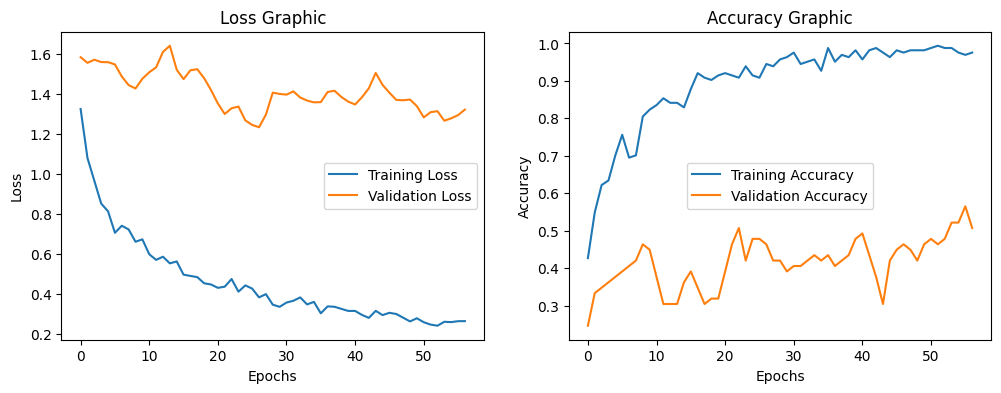

In [23]:
# Plotando o histórico de treinamento após o treinamento
os.makedirs(f"{results_dir}/final", exist_ok=True)
plot_training_history(history_fine_tunning, f"{results_dir}/final", "fine_tunning_oasis_training_history.png")

### PREDIÇÃO VALIDAÇÃO

2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 211ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
              precision    recall  f1-score   support

           0       0.65      0.65      0.65        40
           1       0.28      0.22      0.24        23
           2       0.36      0.67      0.47         6

    accuracy                           0.51        69
   macro avg       0.43      0.51      0.45        69
weighted avg       0.50      0.51      0.50        69



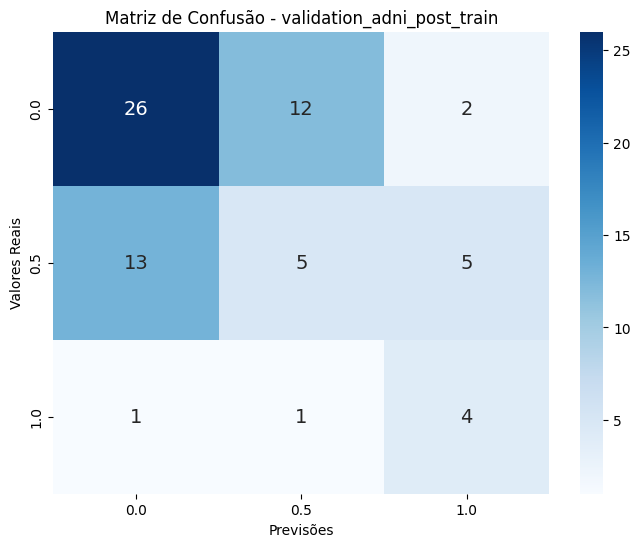

In [24]:
# Realizar predições para dados do conjunto validação
val_pred_labels_post_train, val_true_labels_post_train, val_pred_post_train = get_predictions(val_images_fine_tunning, val_labels_fine_tunning, batch_size, model)

# Obter métricas da valiadação e salvá-las em um arquivo
get_classification_report(val_true_labels_post_train, val_pred_labels_post_train, f"{results_dir}/final", 'validation_adni_post_train')

# Obter matriz de confusão
plot_confusion_matrix(val_true_labels_post_train, val_pred_labels_post_train, f"{results_dir}/final", 'validation_adni_post_train', oasis_class_names)

# Criar pdf com predições
val_pdf_path_post_train = os.path.join(f"{results_dir}/final", "validation_adni_predictions_post_train.pdf")
create_pdf(val_paths_fine_tunning, val_images_fine_tunning, val_true_labels_post_train, val_pred_labels_post_train, val_pred_post_train, val_pdf_path_post_train, oasis_class_names)

### PREDIÇÃO TESTE

Passo 1: Coletando lista de arquivos...
Total de 227 imagens encontradas.
Passo 2: Determinando o shape da imagem...
Shape detectado: (156, 195, 160). Alocando memória para 227 imagens...
Passo 3: Carregando e transformando imagens...
Processado 50/227...
Processado 100/227...
Processado 150/227...
Processado 200/227...
Passo 4: Carregamento concluído.
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 267ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 222ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 224ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 1s/step  
              precision    recall  f1-score   support

           0       0.33      1.00      0.50        73
           1       1.00      0.09      0.17        77
           2       0.00      0.00      0.00        77

    accuracy                           0.35       227
   macro avg       0.44      0.36      0.22       227
weighted avg       0.45      0.35      0.22       227



/mnt/c/Users/Paulo Pires/Desktop/Alzheimer_cnn/Alzheimer-CNN-Detection/3dalz/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/mnt/c/Users/Paulo Pires/Desktop/Alzheimer_cnn/Alzheimer-CNN-Detection/3dalz/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/mnt/c/Users/Paulo Pires/Desktop/Alzheimer_cnn/Alzheimer-CNN-Detection/3dalz/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no

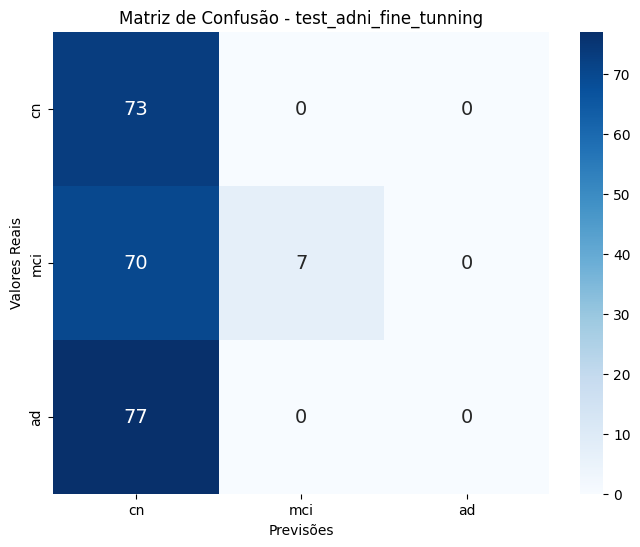

/tmp/ipykernel_719236/1130439845.py:289: RuntimeWarning: invalid value encountered in divide
  img = Image.fromarray(np.uint8(nifti_image / np.max(nifti_image) * 255))  # Normalizar e converter
/tmp/ipykernel_719236/1130439845.py:289: RuntimeWarning: invalid value encountered in cast
  img = Image.fromarray(np.uint8(nifti_image / np.max(nifti_image) * 255))  # Normalizar e converter


In [25]:
test_images_fine_tunning, test_labels_fine_tunning, test_paths_fine_tunning, _ = load_nifti_data_balanced_preallocated(test_dir, adni_class_names)

# Realizar predições para dados do conjunto validação
test_pred_labels_fine_tunning, test_true_labels_fine_tunning, test_pred = get_predictions(test_images_fine_tunning, test_labels_fine_tunning, batch_size, model)

# Obter métricas da valiadação e salvá-las em um arquivo
get_classification_report(test_true_labels_fine_tunning, test_pred_labels_fine_tunning, f"{results_dir}/final", 'test_adni_fine_tunning')

# Obter matriz de confusão
plot_confusion_matrix(test_true_labels_fine_tunning, test_pred_labels_fine_tunning, f"{results_dir}/final", 'test_adni_fine_tunning', adni_class_names)

# Criar pdf com predições
test_pdf_path_fine_tunning = os.path.join(f"{results_dir}/final", "test_adni_predictions_fine_tunning.pdf")
create_pdf(test_paths_fine_tunning, test_images_fine_tunning, test_true_labels, test_pred_labels, test_pred, test_pdf_path, adni_class_names)

### PREDIÇÃO OASIS

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 207ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
              precision    recall  f1-score   support

           0       0.84      0.53      0.65        40
           1       0.38      0.43      0.41        23
           2       0.22      0.67      0.33         6

    accuracy                           0.51        69
   macro avg       0.48      0.54      0.46        69
weighted avg       0.63      0.51      0.54        69



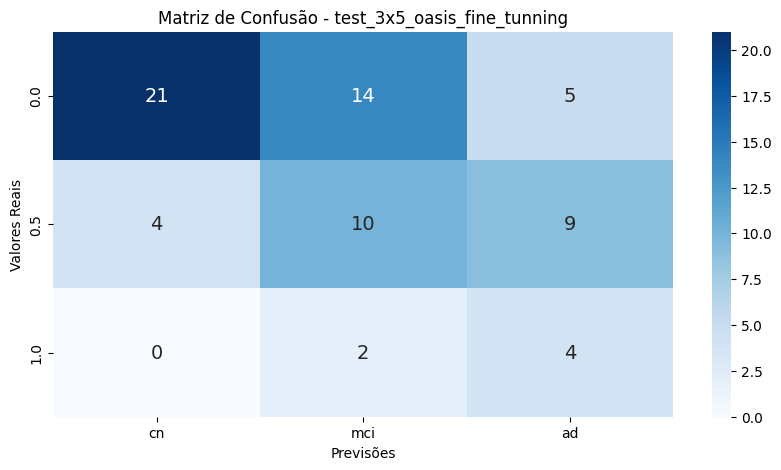

In [26]:
# Realizar predições para dados do conjunto validação
oasis_pred_labels, oasis_true_labels, oasis_pred = get_predictions(oasis_images, oasis_labels, batch_size, model)

# Obter métricas da valiadação e salvá-las em um arquivo
get_classification_report(oasis_true_labels, oasis_pred_labels, f"{results_dir}/final", 'test_oasis_fine_tunning')

# Obter matriz de confusão
cm_adjusted = confusion_matrix(oasis_true_labels, oasis_pred_labels)
plot_custom_confusion_matrix(cm_adjusted, oasis_class_names, adni_class_names, f"{results_dir}/final", 'test_3x5_oasis_fine_tunning')

# # all_possible_numeric_labels = [0.0, 0.5, 1.0, 2.0, 3.0]

# cm_3x3_adjusted = confusion_matrix(oasis_true_labels, gathered_oasis_pred)[0:3, 0:3]

# # Chame a nova função para plotar a matriz ajustada (3x5)
# plot_custom_confusion_matrix(cm_3x3_adjusted, oasis_class_names, oasis_class_names, f"{results_dir}/final", 'test_3x3_oasis_fine_tunning')

# # Criar pdf com predições
oasis_pdf_path = os.path.join(f"{results_dir}/final", "test_oasis_predictions_fine_tunning.pdf")
# create_pdf(oasis_paths, oasis_images, oasis_true_labels, gathered_oasis_pred, oasis_pred, oasis_pdf_path, oasis_class_names)
create_pdf(oasis_paths, oasis_images, oasis_true_labels, oasis_true_labels, oasis_pred, oasis_pdf_path, oasis_class_names)